In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../data/raw/player_season_24_25_data.csv')

In [3]:
print("Shape of dataset: ", df.shape)
print("\nLeague:\n", df['Comp'].value_counts())
print("\nTop 20 position values:\n", df['Pos'].value_counts().head(20))
print("\nDuplicate player+league rows:", df.duplicated(subset=['Player','Comp']).sum())
print("\nTotal unique players:", df['Player'].nunique())

Shape of dataset:  (2854, 267)

League:
 Comp
it Serie A            634
es La Liga            601
eng Premier League    574
fr Ligue 1            553
de Bundesliga         492
Name: count, dtype: int64

Top 20 position values:
 Pos
DF       859
MF       589
FW       371
FW,MF    325
MF,FW    230
GK       212
DF,MF    110
MF,DF     81
DF,FW     53
FW,DF     24
Name: count, dtype: int64

Duplicate player+league rows: 82

Total unique players: 2702


In [4]:
# These are the suffixes FBref appends to duplicated metadata columns
duplicate_suffixes = [
    '_stats_shooting', '_stats_passing', '_stats_passing_types',
    '_stats_gca', '_stats_defense', '_stats_possession',
    '_stats_playing_time', '_stats_misc', '_stats_keeper', '_stats_keeper_adv'
]

cols_to_drop = [
    c for c in df.columns
    if any(sfx in c for sfx in duplicate_suffixes)
]

df_clean = df.drop(columns=cols_to_drop)
print("Columns remaining:", df_clean.shape[1])
print(df_clean.columns.tolist())

Columns remaining: 149
['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'xG', 'npxG', 'xAG', 'npxG+xAG', 'PrgC', 'PrgP', 'PrgR', 'G+A-PK', 'xG+xAG', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'Dist', 'FK', 'npxG/Sh', 'G-xG', 'np:G-xG', 'Cmp', 'Att', 'Cmp%', 'TotDist', 'PrgDist', 'xA', 'A-xAG', 'KP', '1/3', 'PPA', 'CrsPA', 'Live', 'Dead', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 'Off', 'Blocks', 'SCA', 'SCA90', 'PassLive', 'PassDead', 'TO', 'Fld', 'Def', 'GCA', 'GCA90', 'Tkl', 'TklW', 'Def 3rd', 'Mid 3rd', 'Att 3rd', 'Tkl%', 'Lost', 'Pass', 'Int', 'Tkl+Int', 'Clr', 'Err', 'Touches', 'Def Pen', 'Att Pen', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'CPA', 'Mis', 'Dis', 'Rec', 'Mn/MP', 'Min%', 'Mn/Start', 'Compl', 'Subs', 'Mn/Sub', 'unSub', 'PPM', 'onG', 'onGA', '+/-', '+/-90', 'On-Off', 'onxG', 'onxGA', 'xG+/-', 'xG+/-90', '2CrdY', 'Fls', 'PKwon', 'PKcon', '

In [5]:
df_clean = df_clean.copy()
df_clean['PrimaryPos'] = df_clean['Pos'].str.split(',').str[0]
print("Primary positions:\n", df_clean['PrimaryPos'].value_counts())

Primary positions:
 PrimaryPos
DF    1022
MF     900
FW     720
GK     212
Name: count, dtype: int64


In [6]:
df_clean = (df_clean
            .sort_values('Min', ascending=False)
            .drop_duplicates(subset=['Player'], keep='first')
            .reset_index(drop=True))

print("After dedup:", len(df_clean), "players")

After dedup: 2702 players


In [7]:
df_clean = df_clean[df_clean['Min'] >= 300].reset_index(drop=True)

print("After 300-min filter:", len(df_clean), "players")
print("Per league:\n", df_clean['Comp'].value_counts())
print("Per position:\n", df_clean['PrimaryPos'].value_counts())

After 300-min filter: 2111 players
Per league:
 Comp
es La Liga            460
it Serie A            457
eng Premier League    423
fr Ligue 1            391
de Bundesliga         380
Name: count, dtype: int64
Per position:
 PrimaryPos
DF    798
MF    645
FW    505
GK    163
Name: count, dtype: int64


In [8]:
# Rate stats — already per-90 from FBref, use directly
RATE_FEATURES = [
    'Sh/90', 'SoT/90', 'SCA90', 'GCA90',    # attacking threat
    'G/Sh', 'G/SoT',                          # finishing efficiency
]

# Counting stats — need to be divided by 90s to get per-90 rates
COUNT_FEATURES = [
    'Gls', 'Ast', 'xG', 'npxG', 'xAG',
    'PrgC', 'PrgP', 'PrgR',
    'Sh', 'SoT',
    'KP', 'PPA', 'CrsPA',
    'Tkl', 'TklW', 'Int', 'Clr', 'Err',  # Blocks_stats_defense removed
    'Recov',
    'Won',                                  # Lost_stats_misc removed
    'Carries', 'Succ', 'Tkld',
    'Touches', 'Mis', 'Dis',
]

# GK-specific columns (will only be non-zero for GKs)
GK_FEATURES = [
    'GA90', 'Save%', 'CS%',
    '/90',           # PSxG+/-/90 — per-90 version, avoids volume bias of raw PSxG+/-
    '#OPA/90',
    'Stp%', 'AvgDist',
]

# Non-divisible rate/percentage columns
PCT_FEATURES = [
    'Cmp%',      # pass completion
    'Tkl%',      # tackle success
    'Succ%',     # dribble success
    'Won%',      # aerial duel win %
    'SoT%',      # shot accuracy
]

ALL_FEATURES = RATE_FEATURES + COUNT_FEATURES + GK_FEATURES + PCT_FEATURES

# Verify all columns exist
missing = [f for f in ALL_FEATURES if f not in df_clean.columns]
print("Missing columns:", missing)

Missing columns: []


In [9]:
df_feat = df_clean.copy()

# Divide all counting stats by 90s to get per-90 rates
# Avoid division by zero — players with 0 90s shouldn't be here after the filter
for col in COUNT_FEATURES:
    if col in df_feat.columns:
        df_feat[col + '_p90'] = df_feat[col] / df_feat['90s']

# Build final feature matrix column names
COUNT_P90 = [c + '_p90' for c in COUNT_FEATURES if c in df_feat.columns]
FINAL_FEATURES = RATE_FEATURES + COUNT_P90 + GK_FEATURES + PCT_FEATURES
FINAL_FEATURES = [f for f in FINAL_FEATURES if f in df_feat.columns]

print("Total features for clustering:", len(FINAL_FEATURES))

Total features for clustering: 44


In [10]:
# NOTE: League normalization is intentionally NOT applied here before clustering.
#
# Applying league z-scores to df_feat before PCA/K-Means destroys positional signal:
# a GK with Save%=+1.5σ becomes indistinguishable from a striker with Gls_p90=+1.5σ
# in that dimension, causing roles to collapse into "above average" vs "below average"
# blobs rather than genuine position clusters.
#
# League normalization IS applied inside the scoring cell, within each role group,
# so players are scored fairly against peers in their own league.
#
# DO NOT run league normalization before clustering.
print("League normalization deferred to scoring cell. df_feat is unchanged.")

League normalization deferred to scoring cell. df_feat is unchanged.


In [11]:
from sklearn.preprocessing import StandardScaler

# Extract feature matrix
X = df_feat[FINAL_FEATURES].copy()

# Fill NaN with 0 — GK stats are blank for outfield players and vice versa
X = X.fillna(0)

# Z-score standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature matrix shape:", X_scaled.shape)
print("Any NaN remaining:", np.isnan(X_scaled).any())

Feature matrix shape: (2111, 44)
Any NaN remaining: False


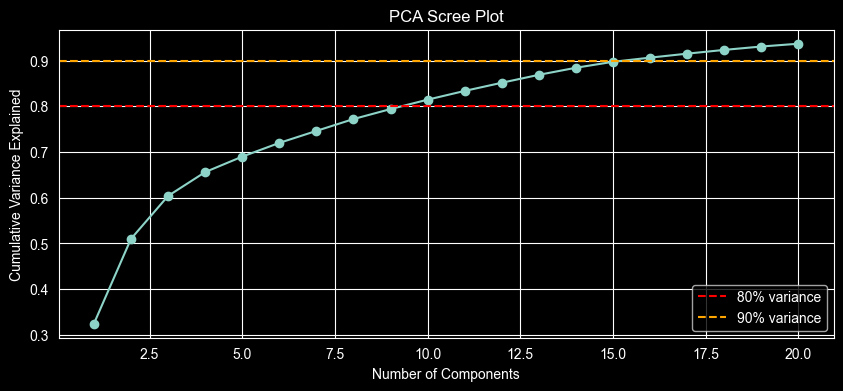

Variance explained by first 10 PCs: 0.815


In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=20)
X_pca = pca.fit_transform(X_scaled)

# Scree plot — see how many components to keep
cumvar = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(10, 4))
plt.plot(range(1, 21), cumvar, marker='o')
plt.axhline(0.80, color='red', linestyle='--', label='80% variance')
plt.axhline(0.90, color='orange', linestyle='--', label='90% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.title('PCA Scree Plot')
plt.legend()
plt.grid(True)
plt.show()

print("Variance explained by first 10 PCs:", cumvar[9].round(3))

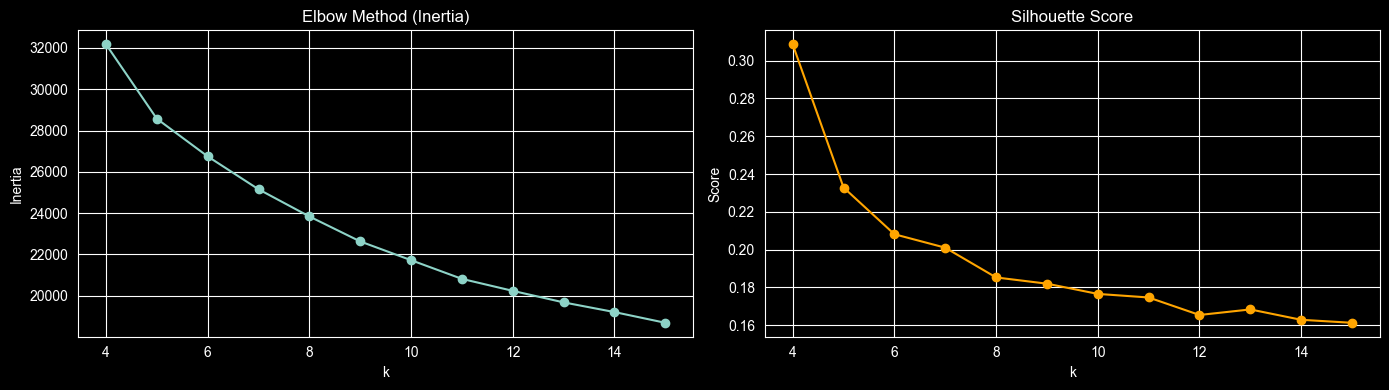

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Use the number of PCs that explain ~85% variance
N_COMPONENTS = 10   # adjust based on scree plot output

X_reduced = X_pca[:, :N_COMPONENTS]

inertias = []
silhouettes = []
K_range = range(4, 16)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_reduced)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_reduced, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(K_range, inertias, marker='o')
ax1.set_title('Elbow Method (Inertia)')
ax1.set_xlabel('k')
ax1.set_ylabel('Inertia')
ax1.grid(True)

ax2.plot(K_range, silhouettes, marker='o', color='orange')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('k')
ax2.set_ylabel('Score')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [14]:
# Set k based on what you saw in Step 13
K = 12   # adjust this after seeing the plots

km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
df_feat['cluster'] = km_final.fit_predict(X_reduced)

print("Players per cluster:\n", df_feat['cluster'].value_counts().sort_index())

Players per cluster:
 cluster
0     256
1     276
2     100
3     193
4     294
5     117
6     116
7      63
8     146
9     150
10    249
11    151
Name: count, dtype: int64


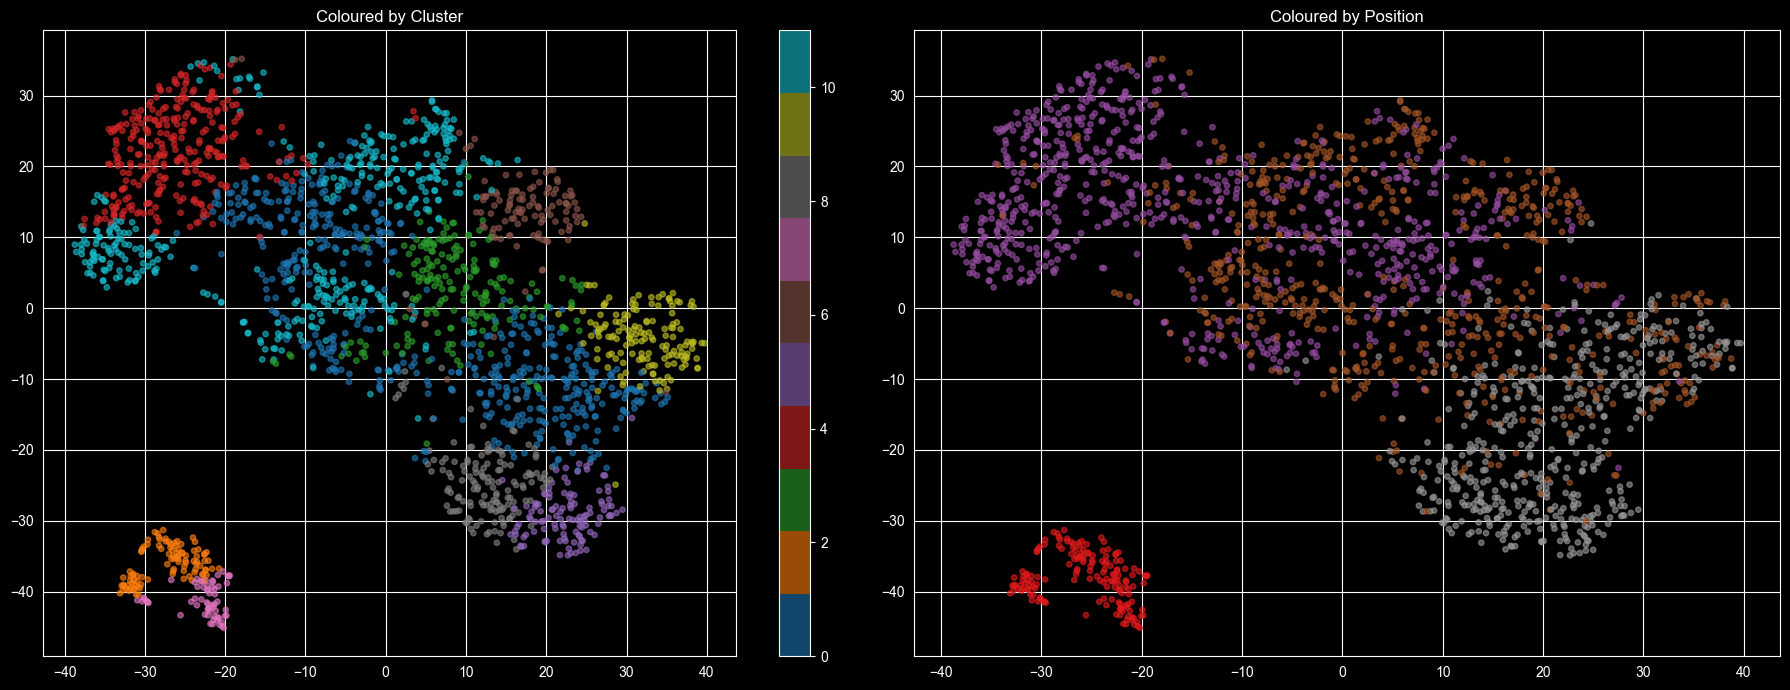

In [15]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=40)
X_tsne = tsne.fit_transform(X_reduced)

df_feat['tsne_x'] = X_tsne[:, 0]
df_feat['tsne_y'] = X_tsne[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Plot coloured by cluster
scatter1 = ax1.scatter(df_feat['tsne_x'], df_feat['tsne_y'],
                       c=df_feat['cluster'], cmap='tab10', alpha=0.6, s=15)
ax1.set_title('Coloured by Cluster')
plt.colorbar(scatter1, ax=ax1)

# Plot coloured by primary position
pos_map = {'GK': 0, 'DF': 1, 'MF': 2, 'FW': 3}
pos_colors = df_feat['PrimaryPos'].map(pos_map).fillna(4)
scatter2 = ax2.scatter(df_feat['tsne_x'], df_feat['tsne_y'],
                       c=pos_colors, cmap='Set1', alpha=0.6, s=15)
ax2.set_title('Coloured by Position')

plt.tight_layout()
plt.show()


In [16]:
for c in sorted(df_feat['cluster'].unique()):
    group = df_feat[df_feat['cluster'] == c]
    print(f"\n{'='*60}")
    print(f"CLUSTER {c}  ({len(group)} players)")
    print(f"Positions: {group['PrimaryPos'].value_counts().to_dict()}")
    print(f"Sample players: {group['Player'].head(10).tolist()}")
    # Raw per-90 averages — easy to interpret after fresh run (no league normalization)
    print(f"  Gls/90:  {group['Gls_p90'].mean():.3f}  "
          f"Ast/90:  {group['Ast_p90'].mean():.3f}  "
          f"xAG/90:  {group['xAG_p90'].mean():.3f}")
    print(f"  SCA90:   {group['SCA90'].mean():.3f}  "
          f"Tkl/90:  {group['Tkl_p90'].mean():.3f}  "
          f"Int/90:  {group['Int_p90'].mean():.3f}")
    print(f"  Cmp%:    {group['Cmp%'].mean():.1f}  "
          f"PrgP/90: {group['PrgP_p90'].mean():.3f}  "
          f"Save%:   {group['Save%'].mean():.1f}")



CLUSTER 0  (256 players)
Positions: {'FW': 154, 'MF': 95, 'DF': 7}
Sample players: ['Antoine Semenyo', 'Morgan Rogers', 'Dodi Lukebakio', 'Jarrod Bowen', 'Aimar Oroz', 'Scott McTominay', 'Ritsu Doan', 'Morgan Gibbs-White', 'Zuriko Davitashvili', 'Andrej Kramarić']
  Gls/90:  0.216  Ast/90:  0.119  xAG/90:  0.129
  SCA90:   2.925  Tkl/90:  1.413  Int/90:  0.471
  Cmp%:    73.0  PrgP/90: 2.841  Save%:   nan

CLUSTER 1  (276 players)
Positions: {'DF': 144, 'MF': 128, 'FW': 4}
Sample players: ['Emmanuel Gyasi', 'Jesper Karlström', 'Omar El Hilali', 'Morten Frendrup', 'Vitaliy Mykolenko', 'Gabriele Zappa', 'Kaishu Sano', 'Simon Sohm', 'Carmona', 'Nahuel Tenaglia']
  Gls/90:  0.024  Ast/90:  0.039  xAG/90:  0.046
  SCA90:   1.475  Tkl/90:  2.059  Int/90:  0.984
  Cmp%:    79.4  PrgP/90: 3.159  Save%:   nan

CLUSTER 2  (100 players)
Positions: {'GK': 100}
Sample players: ['Wladimiro Falcone', 'Jordan Pickford', 'Joan García', 'Matz Sels', 'David Raya', 'Mile Svilar', 'David Soria', 'Dean Hen

In [17]:
CLUSTER_LABELS = {
    0:  'Wide Midfielder / Winger',
    1:  'Defensive Midfielder',
    2:  'Goalkeeper',
    3:  'Fullback / Wing-back',
    4:  'Defensive Centre-back',
    5:  'Clinical Striker',
    6:  'Box-to-box Midfielder',
    7:  'Goalkeeper',
    8:  'Target Man / Physical Striker',
    9:  'Creative Attacking Midfielder',
    10: 'Ball-winning Midfielder',
    11: 'Ball-playing Centre-back',
}

df_feat['role'] = df_feat['cluster'].map(CLUSTER_LABELS)

print("Role distribution:")
print(df_feat['role'].value_counts())


Role distribution:
role
Defensive Centre-back            294
Defensive Midfielder             276
Wide Midfielder / Winger         256
Ball-winning Midfielder          249
Fullback / Wing-back             193
Goalkeeper                       163
Ball-playing Centre-back         151
Creative Attacking Midfielder    150
Target Man / Physical Striker    146
Clinical Striker                 117
Box-to-box Midfielder            116
Name: count, dtype: int64


In [18]:
# Position enforcement — reassign misclassified players to nearest position-compatible cluster
# Uses Euclidean distance in PCA space to find the best-fitting correct cluster

ROLE_EXPECTED_POS_BROAD = {
    'Goalkeeper':                    ['GK'],
    'Defensive Centre-back':         ['DF'],
    'Ball-playing Centre-back':      ['DF'],
    'Fullback / Wing-back':          ['DF'],
    'Defensive Midfielder':          ['MF', 'DF'],
    'Ball-winning Midfielder':       ['MF', 'DF'],
    'Box-to-box Midfielder':         ['MF', 'DF'],
    'Creative Attacking Midfielder': ['MF', 'FW'],
    'Wide Midfielder / Winger':      ['MF', 'FW'],
    'Clinical Striker':              ['FW', 'MF'],
    'Target Man / Physical Striker': ['FW', 'MF'],
}

centroids = km_final.cluster_centers_
reassigned = 0

for i in df_feat.index:
    player_pos = df_feat.at[i, 'PrimaryPos']
    current_role = df_feat.at[i, 'role']
    expected_pos = ROLE_EXPECTED_POS_BROAD.get(current_role, [])

    if player_pos not in expected_pos:
        # Find all clusters whose role accepts this player's position
        valid_clusters = [
            c for c, role in CLUSTER_LABELS.items()
            if player_pos in ROLE_EXPECTED_POS_BROAD.get(role, [])
        ]
        if valid_clusters:
            loc = df_feat.index.get_loc(i)
            player_vec = X_reduced[loc]
            dists = [np.linalg.norm(player_vec - centroids[c]) for c in valid_clusters]
            best_c = valid_clusters[int(np.argmin(dists))]
            df_feat.at[i, 'cluster'] = best_c
            df_feat.at[i, 'role'] = CLUSTER_LABELS[best_c]
            reassigned += 1

print(f"Reassigned {reassigned} players to position-compatible clusters")
print(f"Remaining mismatches: {df_feat.apply(lambda r: r['PrimaryPos'] not in ROLE_EXPECTED_POS_BROAD.get(r['role'], []), axis=1).sum()}")
print("\nUpdated role distribution:")
print(df_feat['role'].value_counts())

Reassigned 121 players to position-compatible clusters
Remaining mismatches: 0

Updated role distribution:
role
Defensive Midfielder             299
Wide Midfielder / Winger         287
Defensive Centre-back            282
Ball-winning Midfielder          270
Goalkeeper                       163
Target Man / Physical Striker    148
Creative Attacking Midfielder    145
Box-to-box Midfielder            135
Fullback / Wing-back             133
Ball-playing Centre-back         132
Clinical Striker                 117
Name: count, dtype: int64


In [19]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

# Anchor feature per role — the one stat that MUST load positively on PC1.
# If PC1 loads negatively on this anchor, flip all scores before normalizing.
ROLE_ANCHORS = {
    'Clinical Striker':                'Gls_p90',
    'Target Man / Physical Striker':   'Gls_p90',
    'Creative Attacking Midfielder':   'xAG_p90',
    'Wide Midfielder / Winger':        'SCA90',
    'Box-to-box Midfielder':           'PrgP_p90',
    'Defensive Midfielder':            'Tkl_p90',
    'Ball-playing Centre-back':        'Int_p90',
    'Ball-winning Midfielder':         'Tkl_p90',
    'Defensive Centre-back':           'Int_p90',
    'Fullback / Wing-back':            'PrgP_p90',
    'Goalkeeper':                      '/90',
}

ROLE_EXPECTED_POS = {
    'Goalkeeper':                      ['GK'],
    'Defensive Centre-back':           ['DF'],
    'Ball-playing Centre-back':        ['DF'],
    'Fullback / Wing-back':            ['DF'],
    'Defensive Midfielder':            ['MF', 'DF'],
    'Box-to-box Midfielder':           ['MF', 'DF'],
    'Ball-winning Midfielder':         ['MF', 'DF'],
    'Creative Attacking Midfielder':   ['MF', 'FW'],
    'Wide Midfielder / Winger':        ['MF', 'FW'],
    'Clinical Striker':                ['FW', 'MF'],
    'Target Man / Physical Striker':   ['FW', 'MF'],
}

df_feat['overall'] = 0.0

for role, group_idx in df_feat.groupby('role').groups.items():
    group = df_feat.loc[group_idx]

    if len(group) < 5:
        continue

    X_role = group[FINAL_FEATURES].fillna(0).values.copy()
    leagues = group['Comp'].values

    # League normalization within role group:
    # Z-score each feature by league so players are ranked relative to their league peers.
    # Only applies when a league contributes >= 5 players to this role group.
    for feat_idx in range(len(FINAL_FEATURES)):
        for league in np.unique(leagues):
            mask = leagues == league
            if mask.sum() < 5:
                continue
            col = X_role[mask, feat_idx]
            std_val = col.std()
            if std_val > 1e-8:
                X_role[mask, feat_idx] = (col - col.mean()) / std_val
            else:
                X_role[mask, feat_idx] = 0.0

    # Global z-score within role group (after league normalization)
    scaler_grp = StandardScaler()
    G_scaled = scaler_grp.fit_transform(X_role)

    # PCA(n=1) — captures main performance dimension
    pca_grp = PCA(n_components=1)
    scores = pca_grp.fit_transform(G_scaled).flatten()

    # Flip check — anchor feature must load positively on PC1
    anchor = ROLE_ANCHORS.get(role)
    if anchor and anchor in FINAL_FEATURES:
        anchor_idx = FINAL_FEATURES.index(anchor)
        if pca_grp.components_[0][anchor_idx] < 0:
            scores = -scores

    # Normalize to 0–100
    min_max = MinMaxScaler(feature_range=(0, 100))
    scores_norm = min_max.fit_transform(scores.reshape(-1, 1)).flatten()

    df_feat.loc[group_idx, 'overall'] = scores_norm

# Flag position mismatches
df_feat['pos_match'] = df_feat.apply(
    lambda r: r['PrimaryPos'] in ROLE_EXPECTED_POS.get(r['role'], []),
    axis=1
)

mismatches = df_feat[~df_feat['pos_match']][['Player', 'PrimaryPos', 'role', 'overall']]
print(f"Misclassified players: {len(mismatches)}")
if len(mismatches) > 0:
    print(mismatches.sort_values('overall', ascending=False).head(15).to_string(index=False))

print()
for role in sorted(df_feat['role'].unique()):
    top5 = (df_feat[df_feat['role'] == role]
            .nlargest(5, 'overall')[['Player', 'Squad', 'Comp', 'overall']])
    print(f"\n── {role} ──")
    print(top5.to_string(index=False))


Misclassified players: 0


── Ball-playing Centre-back ──
         Player          Squad               Comp    overall
   Jan Bednarek    Southampton eng Premier League 100.000000
 Giovanni Leoni          Parma         it Serie A  99.639876
Matija Nastasić        Leganés         es La Liga  98.359638
    Conor Coady Leicester City eng Premier League  97.865798
  Diego Coppola  Hellas Verona         it Serie A  96.126608

── Ball-winning Midfielder ──
        Player           Squad               Comp    overall
   Saúl Ñíguez         Sevilla         es La Liga 100.000000
 Nico O’Reilly Manchester City eng Premier League  97.413684
Kamory Doumbia           Brest         fr Ligue 1  97.229967
    Luka Sučić   Real Sociedad         es La Liga  91.659702
   Diego Gómez        Brighton eng Premier League  90.489790

── Box-to-box Midfielder ──
                Player         Squad               Comp    overall
       Ismaël Bennacer     Marseille         fr Ligue 1 100.000000
       Kieran Tr

In [20]:
import os

output_dir = '../output'
os.makedirs(output_dir, exist_ok=True)

cols = ['Player', 'Squad', 'Comp', 'PrimaryPos', 'role', 'overall', 'Min', '90s']
df_out = df_feat[cols].copy()
df_out.columns = ['name', 'team', 'league', 'position', 'role', 'overall', 'minutes', '90s']
df_out['overall'] = df_out['overall'].round(1)
df_out = df_out.sort_values('overall', ascending=False).reset_index(drop=True)

out_path = os.path.join(output_dir, 'player_overalls.csv')
df_out.to_csv(out_path, index=False)

print(f"Saved {len(df_out)} players → {out_path}")
print(f"\nTop 20 overall:\n{df_out.head(20).to_string(index=False)}")


Saved 2111 players → ../output\player_overalls.csv

Top 20 overall:
             name            team             league position                          role  overall  minutes  90s
     Jan Bednarek     Southampton eng Premier League       DF      Ball-playing Centre-back    100.0     2531 28.1
    Yehvann Diouf           Reims         fr Ligue 1       GK                    Goalkeeper    100.0     3060 34.0
 Dominik Javorček   Holstein Kiel      de Bundesliga       DF          Fullback / Wing-back    100.0      386  4.3
      Saúl Ñíguez         Sevilla         es La Liga       MF       Ball-winning Midfielder    100.0     1553 17.3
Joël Schingtienne         Venezia         it Serie A       DF          Defensive Midfielder    100.0     1122 12.5
Charlie Cresswell        Toulouse         fr Ligue 1       DF         Defensive Centre-back    100.0     2592 28.8
       Chris Wood Nott'ham Forest eng Premier League       FW Target Man / Physical Striker    100.0     2959 32.9
  Ismaël Ben